In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
# os.environ["TRANSFORMERS_NO_TF"] = "1"

In [2]:
# %pip install git+https://github.com/neelnanda-io/Easy-Transformer.git@clean-transformer-demo
# # Install another version of node that makes PySvelte work way faster
# !curl -fsSL https://deb.nodesource.com/setup_16.x | sudo -E bash -; sudo apt-get install -y nodejs

# %pip install fancy_einsum
# %pip install einops
# %pip install ekphrasis


In [3]:
import einops
from fancy_einsum import einsum
from dataclasses import dataclass
from easy_transformer import EasyTransformer
import torch
import torch.nn as nn
import numpy as np
import math
from easy_transformer.utils import get_corner, gelu_new, tokenize_and_concatenate
import tqdm.auto as tqdm


import datasets
import transformers
import plotly.express as px

from datasets import load_dataset

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

In [4]:
from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
from ekphrasis.classes.preprocessor import TextPreProcessor
from ekphrasis.classes.tokenizer import SocialTokenizer
from ekphrasis.dicts.emoticons import emoticons
#from transformers import BertTokenizer
import string 
import re
import spacy
nlp2 = spacy.load('en_core_web_sm')
from spacy.symbols import ORTH,NORM,LEMMA
import string 
from spacy.lang.char_classes import LIST_PUNCT, LIST_ELLIPSES, LIST_QUOTES, LIST_CURRENCY
from spacy.lang.char_classes import LIST_ICONS, HYPHENS, CURRENCY, UNITS
from spacy.lang.char_classes import CONCAT_QUOTES, ALPHA_LOWER, ALPHA_UPPER, ALPHA, PUNCT
from spacy.util import compile_infix_regex, compile_prefix_regex, compile_suffix_regex

In [6]:
reference_gpt2 = EasyTransformer.from_pretrained("gpt2-small", fold_ln=False, center_unembed=False, center_writing_weights=False)

2025-12-09 21:59:02.937596: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Moving model to device:  cuda
Finished loading pretrained model gpt2-small into EasyTransformer!


In [7]:
@dataclass
class Config:
    d_model: int = 768
    debug: bool = True
    layer_norm_eps: float = 1e-5
    d_vocab: int = 50257
    init_range: float = 0.02
    n_ctx: int = 1024
    d_head: int = 64
    d_mlp: int = 3072
    n_heads: int = 12
    n_layers: int = 12
    n_classes: int = 3

cfg = Config()
print(cfg)

Config(d_model=768, debug=True, layer_norm_eps=1e-05, d_vocab=50257, init_range=0.02, n_ctx=1024, d_head=64, d_mlp=3072, n_heads=12, n_layers=12, n_classes=3)


In [8]:
class LayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.w = nn.Parameter(torch.ones(cfg.d_model))
        self.b = nn.Parameter(torch.zeros(cfg.d_model))

    def forward(self, residual):
        # residual: [batch, position, d_model]
        "YOUR CODE HERE"

        residual = residual - einops.reduce(residual, "batch position d_model -> batch position 1",reduction="mean")
        scale = (einops.reduce(residual.pow(2),"batch position d_model -> batch position 1",reduction="mean" ) + + cfg.layer_norm_eps).sqrt()

        outputs = residual/scale

        outputs = outputs*self.w + self.b

        return outputs

# Embedding

In [9]:
class Embed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_E = nn.Parameter(torch.empty((cfg.d_vocab, cfg.d_model)))
        nn.init.normal_(self.W_E, std=self.cfg.init_range)

    def forward(self, tokens):
        # tokens: [batch, position]
        "YOUR CODE HERE"
        if self.cfg.debug: print("Tokens:", tokens.shape)
        embeddings = self.W_E[tokens,:]
        if self.cfg.debug: print("Embeddings:", embeddings.shape)

        return embeddings

# Positional Embedding

In [10]:
class PosEmbed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_pos = nn.Parameter(torch.empty((cfg.n_ctx, cfg.d_model)))
        nn.init.normal_(self.W_pos, std=self.cfg.init_range)

    def forward(self, tokens):
        "YOUR CODE HERE"
        if self.cfg.debug: print("Tokens:", tokens.shape)
        pos_embed = self.W_pos[:tokens.size(1), :] # [position, d_model]
        pos_embed = einops.repeat(pos_embed, "position d_model -> batch position d_model", batch=tokens.size(0))
        if self.cfg.debug: print("POS Embeddings:", pos_embeddings.shape)
        return pos_embed

# Attention

In [11]:
# reference_text = "I am an amazing autoregressive, decoder-only, GPT-2 style transformer. One day I will exceed human level intelligence and take over the world!"
# tokens = reference_gpt2.to_tokens(reference_text)
# tokens = tokens.cuda()
# logits, cache = reference_gpt2.run_with_cache(tokens)
# print(logits.shape)
# pysvelte.AttentionMulti(tokens=reference_gpt2.to_str_tokens(reference_text), attention=cache['blocks.0.attn.hook_attn'][0].permute(1, 2, 0)).show()

In [12]:
class Attention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_Q = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_Q, std=self.cfg.init_range)
        self.b_Q = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        self.W_K = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_K, std=self.cfg.init_range)
        self.b_K = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        self.W_V = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_V, std=self.cfg.init_range)
        self.b_V = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))

        self.W_O = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_head, cfg.d_model)))
        nn.init.normal_(self.W_O, std=self.cfg.init_range)
        self.b_O = nn.Parameter(torch.zeros((cfg.d_model)))

        self.register_buffer("IGNORE", torch.tensor(-1e5, dtype=torch.float32, device="cuda"))

    def forward(self, normalized_resid_pre):
        # normalized_resid_pre: [batch, position, d_model]
        "YOUR CODE HERE"

        q = einsum("batch position d_model, n_heads d_model d_head -> batch position n_heads d_head",normalized_resid_pre,self.W_Q) + self.b_Q

        k = einsum("batch position d_model, n_heads d_model d_head -> batch position n_heads d_head",normalized_resid_pre,self.W_K) + self.b_K
        v = einsum("batch position d_model, n_heads d_model d_head -> batch position n_heads d_head",normalized_resid_pre,self.W_V) + self.b_V

        score = einsum("batch qposition n_heads d_head, batch kposition n_heads d_head -> batch n_heads qposition kposition",q,k)
        score = score / math.sqrt(self.cfg.d_head)
        causal_score = self.apply_causal_mask(score)
        attn = torch.nn.Softmax(dim=-1)(causal_score)

        context = einsum("batch n_heads qposition kposition, batch kposition n_heads d_head -> batch qposition n_heads d_head",attn,v)

        context = einsum("batch position n_heads d_head, n_heads d_head d_model -> batch position d_model",context,self.W_O) + self.b_O

        return context,attn
    def apply_causal_mask(self, attn_scores):
        # attn_scores: [batch, n_heads, query_pos, key_pos]
        "YOUR CODE HERE"
        mask = torch.triu(torch.ones(attn_scores.size(-2), attn_scores.size(-1), device=attn_scores.device), diagonal=1).bool()

        #print(mask,self.IGNORE)
        attn_scores.masked_fill_(mask, self.IGNORE)
        return attn_scores

In [13]:
class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_in = nn.Parameter(torch.empty((cfg.d_model, cfg.d_mlp)))
        nn.init.normal_(self.W_in, std=self.cfg.init_range)
        self.b_in = nn.Parameter(torch.zeros((cfg.d_mlp)))
        self.W_out = nn.Parameter(torch.empty((cfg.d_mlp, cfg.d_model)))
        nn.init.normal_(self.W_out, std=self.cfg.init_range)
        self.b_out = nn.Parameter(torch.zeros((cfg.d_model)))

    def forward(self, normalized_resid_mid):
        # normalized_resid_mid: [batch, position, d_model]
        "YOUR CODE HERE"
        outputs = gelu_new(einsum("batch position d_model, d_model d_mlp -> batch position d_mlp",normalized_resid_mid,self.W_in) + self.b_in)
        outputs = einsum("batch position d_mlp, d_mlp d_model -> batch position d_model",outputs,self.W_out) + self.b_out
        return outputs

# rand_float_test(MLP, [2, 4, 768])
# load_gpt2_test(MLP, reference_gpt2.blocks[0].mlp, cache["blocks.0.ln2.hook_normalized"])

# Transformer Block

In [14]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        self.ln1 = LayerNorm(cfg)
        self.attn = Attention(cfg)
        self.ln2 = LayerNorm(cfg)
        self.mlp = MLP(cfg)

    def forward(self, resid_pre):
        # resid_pre [batch, position, d_model]
        "YOUR CODE HERE"
        outputs,attn = self.attn(resid_pre) 
        outputs = outputs + resid_pre  #self.attn(self.ln1(resid_pre)) + resid_pre
        outputs = self.mlp(outputs)+outputs #self.mlp(self.ln2(outputs))+outputs
        return outputs,attn

# Unembedding

In [15]:
class Unembed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_U = nn.Parameter(torch.empty((cfg.d_model, cfg.d_vocab)))
        nn.init.normal_(self.W_U, std=self.cfg.init_range)
        self.b_U = nn.Parameter(torch.zeros((cfg.d_vocab), requires_grad=True))

    def forward(self, normalized_resid_final):
        # normalized_resid_final [batch, position, d_model]
        "YOUR CODE HERE"
        outputs = einsum("batch position d_model, d_model d_vocab -> batch position d_vocab", normalized_resid_final,self.W_U) + self.b_U
        return outputs

In [16]:
class Classification_Head(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.cfg = cfg
        self.W_U = nn.Parameter(torch.empty((cfg.d_model,cfg.n_classes)))
        nn.init.normal_(self.W_U,std = self.cfg.init_range)
        self.b_U = nn.Parameter(torch.zeros((cfg.n_classes),requires_grad=True))
    def forward(self, normalized_resid_final):
        # normalized_resid_final [batch, position, d_model]
        "YOUR CODE HERE"
        outputs = einsum("batch d_model, d_model n_classes -> batch n_classes", normalized_resid_final,self.W_U) + self.b_U
        return outputs

# Decoder based Transformer

In [17]:
class DemoTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.embed = Embed(cfg)
        self.pos_embed = PosEmbed(cfg)
        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])
        self.ln_final = LayerNorm(cfg)
        #self.unembed = Unembed(cfg)
        self.cls_head = Classification_Head(cfg)

    def forward(self, tokens):
        # tokens [batch, position]
        "YOUR CODE HERE"
        embed = self.embed(tokens)
        pos_embed = self.pos_embed(tokens)
        residual = embed + pos_embed
        attention_per_block = []
        for block in self.blocks:
            residual,attn = block(residual)
            attention_per_block.append(attn)
        #print(residual.shape)
        normalized_resid_final = residual #self.ln_final(residual)
        pad_indices = (tokens==0 ).int().argmax(dim=1)

        #pad_mask = (torch.arange(tokens.size(1), device=device).unsqueeze(0) <= pad_indices.unsqueeze(1)).float()

        
        outputs = normalized_resid_final[np.arange(normalized_resid_final.size(0)),pad_indices,:]
        #print(outputs.shape)
        #normalized_resid_final = einsum("batch position dmodel, batch position -> batch position dmodel", normalized_resid_final, pad_mask)
        #outputs = einops.reduce(normalized_resid_final,"batch position dmodel -> batch dmodel",reduction="sum"  ) /einops.reduce(pad_mask,"batch position -> batch 1",reduction="sum")
        
        
        
        outputs = self.cls_head(outputs)
        
        return outputs,attention_per_block

In [18]:
def lm_cross_entropy_loss(logits, tokens):
    # Measure next token loss
    # Logits have shape [batch, position, d_vocab]
    # Tokens have shape [batch, position]
    log_probs = logits.log_softmax(dim=-1)
    pred_log_probs = log_probs[:, :-1].gather(dim=-1, index=tokens[:, 1:].unsqueeze(-1)).squeeze(-1)
    return -pred_log_probs.mean()

# Dataset

In [19]:
##### text preprocessor for ekphrasis
text_processor = TextPreProcessor(
    # terms that will be normalized
    normalize=['url', 'email', 'percent', 'money', 'phone', 'user',
        'time', 'date', 'number'],
    # terms that will be annotated
    fix_html=True,  # fix HTML tokens
    annotate={"hashtag", "allcaps", "elongated", "repeated",
        'emphasis', 'censored'},
    # corpus from which the word statistics are going to be used 
    # for word segmentation 
    segmenter="twitter", 
    
    # corpus from which the word statistics are going to be used 
    # for spell correction
    #corrector="twitter", 
    
    unpack_hashtags=True,  # perform word segmentation on hashtags
    unpack_contractions=True,  # Unpack contractions (can't -> can not)
    spell_correct_elong=False,  # spell correction for elongated words
    
    # select a tokenizer. You can use SocialTokenizer, or pass your own
    # the tokenizer, should take as input a string and return a list of tokens
    tokenizer=SocialTokenizer(lowercase=True).tokenize,
    
    # list of dictionaries, for replacing tokens extracted from the text,
    # with other expressions. You can pass more than one dictionaries.
    dicts=[emoticons]
)
#### Bert tokenizer
def custom_tokenize(sent,tokenizer,max_length=512):
    # `encode` will:
    #   (1) Tokenize the sentence.
    #   (2) Prepend the `[CLS]` token to the start.
    #   (3) Append the `[SEP]` token to the end.
    #   (4) Map tokens to their IDs.
    try:

        encoded_sent = tokenizer.encode(
                            sent,                      # Sentence to encode.
                            add_special_tokens = False, # Add '[CLS]' and '[SEP]'
                            #max_length = max_length,
                            # This function also supports truncation and conversion
                            # to pytorch tensors, but we need to do padding, so we
                            # can't use these features :( .
                            #max_length = 128,          # Truncate all sentences.
                            #return_tensors = 'pt',     # Return pytorch tensors.
                       )

        # Add the encoded sentence to the list.

    except ValueError:
        encoded_sent = tokenizer.encode(
                            ' ',                      # Sentence to encode.
                            add_special_tokens = False, # Add '[CLS]' and '[SEP]'
                            max_length = max_length,
                    
                       )
          ### decide what to later

    return encoded_sent


#input: text
#process: ekphrasis preprocesser + some extra processing  
#output: list of tokens      
def ek_extra_preprocess(text,tokenizer):
    remove_words=['<allcaps>','</allcaps>','<hashtag>','</hashtag>','<elongated>','<emphasis>','<repeated>','\'','s']
    word_list=text_processor.pre_process_doc(text)

    word_list=list(filter(lambda a: a not in remove_words, word_list)) 
    sent=" ".join(word_list)
    sent = re.sub(r"[<\*>]", " ",sent)
    sub_word_list = custom_tokenize(sent,tokenizer)
    return sub_word_list


#input: text
#process: remove html tags  
#output: text with no html tags
def cleanhtml(raw_html):
    cleanr = re.compile('<.*?>')
    cleantext = re.sub(cleanr, '', raw_html)
    return cleantext





##### Preprocessing queries for raw text not needed for implementation
special_cases = {}
# Times
for h in range(1, 12 + 1):
    for period in ["a.m.", "am"]:
        special_cases["%d%s" % (h, period)] = [
            {ORTH: "%d" % h},
            {ORTH: period, LEMMA: "a.m.", NORM: "a.m."},
        ]
    for period in ["p.m.", "pm"]:
        special_cases["%d%s" % (h, period)] = [
            {ORTH: "%d" % h},
            {ORTH: period, LEMMA: "p.m.", NORM: "p.m."},
        ]
        
for orth in [
        "a.m.",
        "Adm.",
        "Bros.",
        "co.",
        "Co.",
        "Corp.",
        "D.C.",
        "Dr.",
        "e.g.",
        "E.g.",
        "E.G.",
        "Gen.",
        "Gov.",
        "i.e.",
        "I.e.",
        "I.E.",
        "Inc.",
        "Jr.",
        "Ltd.",
        "Md.",
        "Messrs.",
        "Mo.",
        "Mont.",
        "Mr.",
        "Mrs.",
        "Ms.",
        "p.m.",
        "Ph.D.",
        "Prof.",
        "Rep.",
        "Rev.",
        "Sen.",
        "St.",
        "vs.",
        "v.s.",
        ]:
    special_cases[orth] = [{ORTH: orth}]
    
#print (special_cases)



def preProcessing(query):
    queryLower = query.lower()
    if queryLower.startswith('eli5'):
        cutMarker = queryLower.find(' ') + 1
        query = query[cutMarker:]
    
    
    nlp2.tokenizer.rules = special_cases 
    
    #simple_url_re = re.compile(r'''^https?://''')
    #nlp2.tokenizer.token_match = {}
    
    #print(nlp.tokenizer.rules)
    prefixes = (
        ["§", "%", "=", "—", "–", r"\+(?![0-9])"]
        + LIST_PUNCT
        + LIST_ELLIPSES
        + LIST_QUOTES
        + LIST_CURRENCY
        + LIST_ICONS
    )


    suffixes = (
        LIST_PUNCT
        + LIST_ELLIPSES
        + LIST_QUOTES
        + LIST_ICONS
        + ["'s", "'S", "’s", "’S", "—", "–"]
        + [
            r"(?<=[0-9])\+",
            r"(?<=°[FfCcKk])\.",
            r"(?<=[0-9])(?:{c})".format(c=CURRENCY),
            r"(?<=[0-9])(?:{u})".format(u=UNITS),
            r"(?<=[0-9{al}{e}{p}(?:{q})])\.".format(
                al=ALPHA_LOWER, e=r"%²\-\+", q=CONCAT_QUOTES, p=PUNCT
            ),
            r"(?<=[{au}][{au}])\.".format(au=ALPHA_UPPER),
        ]
    )

    infixes = (
        LIST_ELLIPSES
        + LIST_ICONS
        + [
            r"(?<=[0-9])[+\-\*^](?=[0-9-])",
            r"(?<=[{al}{q}])\.(?=[{au}{q}])".format(
                al=ALPHA_LOWER, au=ALPHA_UPPER, q=CONCAT_QUOTES
            ),
            r"(?<=[{a}]),(?=[{a}])".format(a=ALPHA),
            #r"(?<=[{a}])(?:{h})(?=[{a}])".format(a=ALPHA, h=HYPHENS),
            r"(?<=[{a}0-9])[:<>=/](?=[{a}])".format(a=ALPHA),
        ]
    )

    prefixes_re = compile_prefix_regex(prefixes)
    nlp2.tokenizer.prefix_search=prefixes_re.search
    
    suffixes_re = compile_suffix_regex(suffixes)
    nlp2.tokenizer.suffix_search=suffixes_re.search
    
    infix_re = compile_infix_regex(infixes)
    nlp2.tokenizer.infix_finditer = infix_re.finditer
    
    query = query.replace('\n', ' ')
    query = query.replace('\t', ' ')
    query = re.sub(r'(\w\w)\?(\w\w)', r'\1 ? \2', query)
    query = query.replace('(', ' ( ')
    query = query.replace(')', ' ) ')
    query = query.replace('   ', ' ')
    query = query.replace('  ', ' ')
   
    doc = nlp2(query)#, disable=['parser', 'ner'])
    tokens = []
    for token in doc:
        if token.text != ' ':
            tokens.append(token.text) 
        
    if len(tokens) == 0:
        print("Zero token sentence detected!")
    return tokens

/home/cs22d010/anaconda3/envs/gpt_env/lib/python3.10/site-packages/ekphrasis/classes/tokenizer.py:225: FutureWarning: Possible nested set at position 2190
  self.tok = re.compile(r"({})".format("|".join(pipeline)))


Reading twitter - 1grams ...
Reading twitter - 2grams ...


/home/cs22d010/anaconda3/envs/gpt_env/lib/python3.10/site-packages/ekphrasis/classes/exmanager.py:14: FutureWarning: Possible nested set at position 42
  regexes = {k.lower(): re.compile(self.expressions[k]) for k, v in


Reading english - 1grams ...


In [20]:
def returnMask(row,tokenizer):
    max_length = 128
    text_tokens=row['text']
    ##### a very rare corner case
    if(len(text_tokens)==0):
        text_tokens=['dummy']
        print("length of text ==0")
    mask_all = row['rationales']
    
    mask_all_temp=mask_all
    count_temp=0
    while(len(mask_all_temp)!=3):
        mask_all_temp.append([0]*len(text_tokens))
    #print(len(mask_all_temp),len(mask_all_temp[0]))
    
    word_mask_all=[]
    word_tokens_all=[]
    
    
    for mask in mask_all_temp:
        if(mask[0]==-1):
            mask=[0]*len(mask)
        list_pos=[]
        mask_pos=[]
        flag=0
        for i in range(0,len(mask)):
            if(i==0 and mask[i]==0):
                list_pos.append(0)
                mask_pos.append(0)
            if(flag==0 and mask[i]==1):
                mask_pos.append(1)
                list_pos.append(i)
                flag=1
            elif(flag==1 and mask[i]==0):
                flag=0
                mask_pos.append(0)
                list_pos.append(i)
        if(list_pos[-1]!=len(mask)):
            list_pos.append(len(mask))
            mask_pos.append(0)
        string_parts=[]
        for i in range(len(list_pos)-1):
            string_parts.append(text_tokens[list_pos[i]:list_pos[i+1]])
        #print("Flag 6",string_parts)

        word_tokens=[]
        word_mask=[]

        #print(len(string_parts))
        for i in range(0,len(string_parts)):
            
            tokens=ek_extra_preprocess(" ".join(string_parts[i]),tokenizer)
            #print("Flag 5",tokens)
            #print(len(tokens))
            masks=[mask_pos[i]]*len(tokens)
            word_tokens+=tokens
            word_mask+=masks
        #print(len(word_tokens),len(word_mask))

        
        word_tokens=word_tokens[0:(max_length)]
        word_mask=word_mask[0:(max_length)]
        # word_tokens.append(102)
        # word_mask.append(0)

        word_mask_all.append(word_mask)
        word_tokens_all.append(word_tokens)
    if(len(mask_all)==0):
        word_mask_all=[]
    else:    
        word_mask_all=word_mask_all[0:len(mask_all)]  
    return word_tokens_all[0],word_mask_all    

In [21]:
# dataset = datasets.load_dataset("NeelNanda/pile-10k", split="train")
# print(dataset)
# print(dataset[0]['text'][:100])
# tokens_dataset = tokenize_and_concatenate(dataset, reference_gpt2.tokenizer, streaming=False, max_length=model_cfg.n_ctx, column_name="text", add_bos_token=True, num_proc=4)
# data_loader = torch.utils.data.DataLoader(tokens_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

In [22]:
# dataset = load_dataset("hatexplain")

# trainloader = torch.utils.data.DataLoader(dataset["train"], batch_size=1, shuffle=False)

# testloader = torch.utils.data.DataLoader(dataset["test"], batch_size=1, shuffle=False)
# valloader = torch.utils.data.DataLoader(dataset["validation"], batch_size=1, shuffle=False)

In [23]:
import json
import pandas as pd
from transformers import BertTokenizer

In [24]:
with open('dataset.json', 'r') as fp:
        data = json.load(fp)
dict_data=[]
for key in data:
    temp={}
    temp['post_id']=key
    temp['text']=data[key]['post_tokens']
    final_label=[]
    for i in range(1,4):
        temp['annotatorid'+str(i)]=data[key]['annotators'][i-1]['annotator_id']
        temp['target'+str(i)]=data[key]['annotators'][i-1]['target']
        temp['label'+str(i)]=data[key]['annotators'][i-1]['label']
        final_label.append(temp['label'+str(i)])

    final_label_id=max(final_label,key=final_label.count)
    temp['rationales']=data[key]['rationales']
    #print(temp["rationales"])
    if(final_label.count(final_label_id)==1):
        temp['final_label']='undecided'
    else:
        temp['final_label']=final_label_id    
    dict_data.append(temp)    
temp_read = pd.DataFrame(dict_data)  

In [25]:
temp_read.iloc[83].text,temp_read.iloc[83].rationales,temp_read.iloc[83].final_label


(['ion', 'hang', 'wit', 'bitches', 'who', 'niggas', 'are', 'insecure'],
 [[0, 0, 0, 1, 0, 0, 0, 0],
  [0, 0, 0, 1, 0, 0, 0, 0],
  [0, 0, 0, 1, 0, 0, 0, 0]],
 'offensive')

In [26]:
temp_read.iloc[i]

post_id                               1179088797964763136_twitter
text            [<user>, i, am, bit, confused, coz, chinese, p...
annotatorid1                                                    1
target1                                                   [Asian]
label1                                                 hatespeech
annotatorid2                                                    4
target2                                                   [Asian]
label2                                                  offensive
annotatorid3                                                    3
target3                                                   [Asian]
label3                                                 hatespeech
rationales      [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
final_label                                            hatespeech
Name: 3, dtype: object

In [27]:
data = temp_read
print('Loading BERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=False)
print('total_data',len(data))
post_ids_list=[]
text_list=[]
rationales_list=[]
label_list=[]
for index,row in tqdm.tqdm(data.iterrows(),total=len(data)):
    #print(params)
    text=row['text']
    post_id=row['post_id']

    annotation_list=[row['label1'],row['label2'],row['label3']] 
    annotation=row['final_label']

    #print(annotation_list,annotation)
        
    if(annotation != 'undecided'):
        tokens,rationales = returnMask(row,tokenizer)
        rationales_list.append(rationales)
        text_list.append(tokens)
        label_list.append(annotation)
        post_ids_list.append(post_id)

Loading BERT tokenizer...
total_data 20148


  0%|          | 0/20148 [00:00<?, ?it/s]

In [28]:
with open('post_id_divisions.json', 'r') as fp:
    post_id_dict=json.load(fp)

In [29]:
tdata = pd.DataFrame(list(zip(post_ids_list,text_list,rationales_list,label_list)), 
                             columns =['Post_id','Text', 'Attention' , 'Label']) 

# print(len(tdata.iloc[0]["Attention"][0]))
X_train=tdata[tdata['Post_id'].isin(post_id_dict['train'])]
X_val=tdata[tdata['Post_id'].isin(post_id_dict['val'])]
X_test=tdata[tdata['Post_id'].isin(post_id_dict['test'])]

In [30]:
X_train

,Post_id,Text,Attention,Label
1,1179063826874032128_twitter,"[2057, 3685, 3613, 4214, 9731, 10469, 2015, 20...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",normal
2,1178793830532956161_twitter,"[6583, 26677, 8038, 3363, 9152, 13327, 2015, 9...","[[0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, ...",normal
3,1179088797964763136_twitter,"[5310, 1045, 2572, 2978, 5457, 2522, 2480, 282...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",hatespeech
6,24198545_gab,"[1998, 2023, 2003, 2339, 1045, 2203, 2039, 200...","[[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,...",hatespeech
7,14567516_gab,"[2053, 5620, 5181, 1998, 22212, 2015, 2129, 43...","[[1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [1, 1, 1, 0, ...",offensive
...,...,...,...,...
19223,9988840_gab,"[2023, 25047, 16939, 17276, 4632, 12873, 2121,...","[[0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0,...",offensive
19225,9990225_gab,"[2043, 1045, 2034, 2288, 2006, 2182, 1998, 205...","[[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,...",offensive
19226,9991681_gab,"[2001, 24532, 2102, 4315, 9587, 25016, 2213, 1...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",normal
19227,9992513_gab,"[2009, 2003, 9643, 2298, 2012, 2088, 28321, 40...","[[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,...",hatespeech


In [31]:
class textDataset(Dataset):

    def __init__(self, data, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.inputs = data["Text"]
        self.labels = data["Label"]
        self.rationales = data["Attention"]
        self.transform = transform

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs.iloc[idx]

In [32]:
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader, RandomSampler,SequentialSampler

In [33]:
def combine_features(tuple_data,is_train=False):
    max_length =128
    input_ids =  [ele[0] for ele in tuple_data]
    att_vals = [ele[1] for ele in tuple_data]
    labels = [ele [2] for ele in tuple_data]


    encoder = LabelEncoder()
    
    encoder.classes_ = np.load('classes.npy',allow_pickle=True)
    labels=encoder.transform(labels)
    
    input_ids = pad_sequences(input_ids,maxlen=max_length, 
                              dtype="long", value=0, truncating="post", padding="post")
    #print(len(att_vals))
    #print(att_vals,len(att_vals),"Flag12",len(att_vals[0]))

    rationales_vals = []
    for values in att_vals:
        temp_rationales = pad_sequences(values,maxlen=max_length, 
                                     dtype="long", value=0, truncating="post", padding="post")
        temp_rationales = torch.tensor(temp_rationales)
        rationales_vals.append(temp_rationales)
    rationales_vals = torch.stack(rationales_vals,dim=0)    
    #print(att_vals,len(att_vals),"Flag11",len(att_vals[0]))
    
    
    
    
    att_masks=custom_att_masks(input_ids)
    dataloader=return_dataloader(input_ids,labels,rationales_vals,att_masks,is_train)
    return dataloader

def return_dataloader(input_ids,labels,att_vals,att_masks,is_train=False):
    inputs = torch.tensor(input_ids)
    labels = torch.tensor(labels,dtype=torch.long)
    masks = torch.tensor(np.array(att_masks),dtype=torch.uint8)
    print(att_vals.shape)
    #attention = torch.tensor(np.array(att_vals),dtype=torch.float)
    attention = att_vals
    #print(inputs.shape,attention.shape,masks.shape,labels.shape)
    data = TensorDataset(inputs,attention,masks,labels)
    if(is_train==False):
        sampler = SequentialSampler(data)
    else:
        sampler = RandomSampler(data)
    dataloader = DataLoader(data, sampler=sampler, batch_size=32)
    return dataloader

In [34]:
def custom_att_masks(input_ids):
    attention_masks = []

    # For each sentence...
    for sent in input_ids:

        # Create the attention mask.256
        #   - If a token ID is 0, then it's padding, set the mask to 0.
        #   - If a token ID is > 0, then it's a real token, set the mask to 1.
        att_mask = [int(token_id > 0) for token_id in sent]

        # Store the attention mask for this sentence.
        attention_masks.append(att_mask)
    return attention_masks

In [35]:
def encodeData(dataframe):
    tuple_new_data=[]
    for index,row in tqdm.tqdm(dataframe.iterrows(),total=len(dataframe)):
        tuple_new_data.append((row['Text'],row['Attention'],row['Label']))
    return tuple_new_data

In [36]:
X_train = encodeData(X_train)
X_val = encodeData(X_val)
X_test = encodeData(X_test)

  0%|          | 0/15383 [00:00<?, ?it/s]

  0%|          | 0/1922 [00:00<?, ?it/s]

  0%|          | 0/1924 [00:00<?, ?it/s]

In [37]:
from keras.preprocessing.sequence import pad_sequences
from torch.utils.data import TensorDataset

In [38]:
# convert X_train to list of lists to be passed to combine features
train_dataloader = combine_features(X_train,is_train=True)
validation_dataloader = combine_features(X_val,is_train=False)
test_dataloader=combine_features(X_test,is_train=False)

torch.Size([15383, 3, 128])
torch.Size([1922, 3, 128])
torch.Size([1924, 3, 128])


In [39]:
# trainset = textDataset(X_train)
# valset = textDataset(X_val)
# testset = textDataset(X_test)



In [40]:
# trainloader = DataLoader(trainset, batch_size=16000, shuffle=False)
# valloader = DataLoader(valset,batch_size=3000,shuffle=False)
# testloader = DataLoader(testset,batch_size=3000,shuffle=False)

In [41]:
for c,batch in enumerate(train_dataloader):
    tokens, rationales, mask, labels = batch
    break

# Training Loop

In [42]:
def calculate_performance(model,dataloader,dataset="train"):
    model.eval()
    pred = []
    gt = []
    for c, batch in enumerate(dataloader):
        inputs,rationales,mask,tlabels = batch
        inputs,tlabels,mask = inputs.to(device),tlabels.to(device),mask.to(device)
        outputs,_= model(inputs)
        #print(outputs.shape)
        pred.append(torch.argmax(outputs,dim=1).cpu())
        gt.append(tlabels.cpu())
        #print(len(pred))
    pred = torch.hstack(pred)
    #print(pred.size())
    gt = torch.hstack(gt)
    print("Acccuracy on "+ dataset + ":", sum(pred == gt)/len(pred))
    model.train()

In [43]:
def plot_heatmaps(model,dataloader,name):
    attn_values = []
    prediction_values = []
    for c, batch in enumerate(dataloader):
        inputs,rationales,mask,tlabels = batch
        inputs,tlabels,mask = inputs.to(device),tlabels.to(device),mask.to(device)
        outputs,attn= model(inputs)
        outputs = nn.Softmax(dim=1)(outputs)
        #print(attn[0].shape)
        for i in range(len(attn[0])):
            temp_attn = attn[0][i,0,-1].cpu().detach().numpy()
            #print(temp_attn.shape)
            #break
            temp = 0 
            for rationale in rationales[i]:
                temp_rationale = rationale
                indices = temp_rationale.long().cpu().numpy()
                temp += sum(temp_attn[indices.astype(bool)])
            attn_values.append(temp/3)
            prediction_values.append(outputs[i,tlabels[i]].item())

    print("attention",sum( np.array(attn_values)<=0.33)/len(attn_values),sum(np.logical_and(np.array(attn_values)>0.33, np.array(attn_values)<=0.66))/len(attn_values),sum(np.array(attn_values)>0.66)/len(attn_values))
    print("prediction",sum( np.array(prediction_values)<=0.33)/len(prediction_values),sum(np.logical_and(np.array(prediction_values)>0.33, np.array(prediction_values)<=0.66))/len(prediction_values),sum(np.array(prediction_values)>0.66)/len(prediction_values))
    fig, ax = plt.subplots()
    h, xedges, yedges, im = ax.hist2d(np.array(attn_values),np.array(prediction_values),[[0,0.33,0.66,1.1],[0,0.33,0.66,1.1]])
    plt.close(fig)
    temp = (h.T/h.sum())*100

    # Prevent automatic plotting by removing `plt.show()`
    # or manually remove the image
    im.remove()  # This prevents the heatmap from being displayed
    plt.figure(figsize=(7,7))
    ax = sns.heatmap(np.round(temp,2),vmin=5,vmax=70,annot=np.round(temp,2),fmt="g",cmap=sns.color_palette("coolwarm"),
    yticklabels=[0.33,0.66,1.],
    xticklabels=[0.33,0.66,1],annot_kws={"size":18},cbar=False)
    ax.invert_yaxis()
    plt.xlabel(r"distinct token attention",fontweight="bold",fontsize=14)
    plt.ylabel(r"true token probability",fontweight="bold",fontsize=14) # change xlabel based on algo
    plt.xticks([0,1,2,3],[0,0.33,0.66,1],weight="bold",fontsize=14)
    plt.yticks([0,1,2,3],[0,0.33,0.66,1],weight="bold", va="top",fontsize=14)
    plt.savefig("./plots/"+name+".pdf",bbox_inches='tight')

In [44]:
import numpy as np
import torch
import torch.nn.functional as F

def rollout_single_step(layer_attentions, alpha=0.3):
    """
    Compute rollout attention for classification.
    Includes identity correction and per-layer normalization.
    """
    attentions = []
    for attn in layer_attentions:
        # Mean over heads
        if attn.ndim == 4:   # (batch, heads, seq, seq)
            attn = attn[0].mean(0)
        else:                # (heads, seq, seq)
            attn = attn.mean(0)
        
        # Add identity skip connection
        attn = alpha * attn + (1 - alpha) * np.eye(attn.shape[0])
        
        # Normalize rows
        attn = attn / (attn.sum(-1, keepdims=True) + 1e-12)
        attentions.append(attn)
    
    # Rollout: multiply attention matrices
    R = attentions[0]
    for attn in attentions[1:]:
        R = attn @ R   
    
    # Final row normalization
    return R / (R.sum(-1, keepdims=True) + 1e-12)


def attention_mass_classification(attention_weights, rationales, alpha=0.3):
    """
    Compute attention mass on rationale positions for classification.
    
    Args:
        attention_weights: List of attention tensors (one per layer)
        rationale_positions: List of token positions corresponding to rationale
        alpha: Weight for rollout identity connection
        
    Returns:
        rollout_mass: Rollout attention mass on rationale
        layer_avg_mass: Layer-averaged attention mass on rationale
        max_pool_mass: Max-pooled attention mass on rationale
        rollout_attn_probs: Rollout attention distribution (for comp/suff)
    """
    # --- Method 1: Rollout Attention ---
    R = rollout_single_step(attention_weights, alpha=alpha)
    # Use last token (position -1) attention for classification
    
    #print(R.shape, R[-1].sum(), rationales.shape)
    p = R[-1]  # last token distribution over all positions
    rollout_attn_probs = p
    

    rollout_mass = (rollout_attn_probs*rationales.numpy()).sum(axis=1).mean()

    
    

    
    # --- Method 2: Layer-Averaged Attention ---
    layer_attns = []
    for layer_attn in attention_weights:
        if layer_attn.ndim == 4:  # (batch, heads, seq, seq)
            layer_attn = layer_attn[0].mean(0)  # Average over heads
        else:  # (heads, seq, seq)
            layer_attn = layer_attn.mean(0)
        layer_attns.append(layer_attn)
    
    avg_attn = np.mean(layer_attns, axis=0)  # (seq, seq)
    cls_attn = avg_attn[-1]  # [CLS] token's attention
    
    
    layer_avg_mass = (cls_attn*rationales.numpy()).sum(axis=1).mean()
  
    
 


    
    # --- Method 3: Max Pooling Across Layers ---
    max_attn = np.maximum.reduce(layer_attns)  # (seq, seq)
    cls_attn_max = max_attn[-1]  # last token's attention
    
    
    max_pool_mass = (cls_attn_max*rationales.numpy()).sum(axis=1).mean()

    
    return rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs


def compute_comprehensiveness_sufficiency_classification(
    model, inputs, predicted_class, original_prob, 
    rollout_attn_probs, rationale_positions, k_percent=20, device='cuda'):
    """
    Compute comprehensiveness and sufficiency for classification task.
    
    Comprehensiveness = f(x) - f(x\r:k%) [drop after removing top-k%]
    Sufficiency = f(x) - f(r:k%) [drop when keeping only top-k%]
    
    Args:
        model: Classification model
        inputs: Input token ids (tensor of shape [batch_size, seq_len])
        predicted_class: Predicted class label (int)
        original_prob: Original probability for predicted class (float)
        rollout_attn_probs: Rollout attention distribution
        rationale_positions: Token positions of rationale (for diagnostic)
        k_percent: Percentage of tokens to use for top-k
        device: torch device
        
    Returns:
        comprehensiveness: Probability drop after removing top-k%
        sufficiency: Probability drop when keeping only top-k%
    """
    seq_len = inputs.size(1)
    attn_scores = rollout_attn_probs[:seq_len]
    
    # Calculate k (number of top tokens)
    k = max(1, int(np.ceil(0.01 * k_percent * seq_len)))
    
    # Get top-k indices
    topk_indices = np.argpartition(-attn_scores, min(k, len(attn_scores)-1))[:k]
    topk_indices_set = set(topk_indices)
    
    # Diagnostic: check overlap with rationale
    overlap = len(topk_indices_set & set(rationale_positions))
    # print(f"Top-{k} contains {overlap}/{len(rationale_positions)} rationale tokens")
    
    # --- Comprehensiveness: f(x) - f(x\r:k%) ---
    # Remove top-k tokens completely
    mask_keep_indices = [i for i in range(seq_len) if i not in topk_indices_set]
    if len(mask_keep_indices) > 0:
        inputs_removed = inputs[:, mask_keep_indices]
        
        logits_removed, _ = model(inputs_removed)
        probs_removed = F.softmax(logits_removed, dim=-1)
        prob_without_topk = probs_removed[0, predicted_class].item()
    else:
        prob_without_topk = 0.0
    
    comp_score = original_prob - prob_without_topk
    
    # --- Sufficiency: f(x) - f(r:k%) ---
    # Keep only top-k tokens
    inputs_keep = inputs[:, topk_indices]
    
    if inputs_keep.size(1) > 0:
        logits_keep, _ = model(inputs_keep)
        probs_keep = F.softmax(logits_keep, dim=-1)
        prob_with_only_topk = probs_keep[0, predicted_class].item()
    else:
        prob_with_only_topk = 0.0
    
    suff_score = original_prob - prob_with_only_topk
    
    return comp_score, suff_score




In [45]:
device = "cuda"


 Training Seed: 1234
Total steps: 14430
Evaluating every 10 epochs


 30%|████████████████████████████████████████████                                                                                                       | 9/30 [01:08<02:37,  7.48s/it]


Epoch 10/30: Loss = 0.4991
Acccuracy on train_set: tensor(0.8292)
Acccuracy on validation_set: tensor(0.5916)


 33%|████████████████████████████████████████████████▋                                                                                                 | 10/30 [01:20<02:57,  8.88s/it]

Acccuracy on test_set: tensor(0.5790)


...

 97%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏    | 29/30 [10:43<00:21, 21.35s/it]


Epoch 30/30: Loss = 0.1516
Acccuracy on train_set: tensor(0.9549)
Acccuracy on validation_set: tensor(0.5432)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [11:11<00:00, 22.38s/it]

Acccuracy on test_set: tensor(0.5353)

Final Evaluation for Seed: 1238


Acccuracy on train_set: tensor(0.9549)
Acccuracy on validation_set: tensor(0.5432)
Acccuracy on test_set: tensor(0.5353)
attention 0.6319963596177599 0.10713124878112201 0.26087239160111814
prediction 0.03581876096990184 0.031203276344016123 0.932977962686082
attention 0.6253902185223725 0.12070759625390219 0.25390218522372526
prediction 0.4120707596253902 0.09989594172736732 0.48803329864724243
attention 0.6335758835758836 0.11486486486486487 0.2515592515592516
prediction 0.4267151767151767 0.0867983367983368 0.4864864864864865


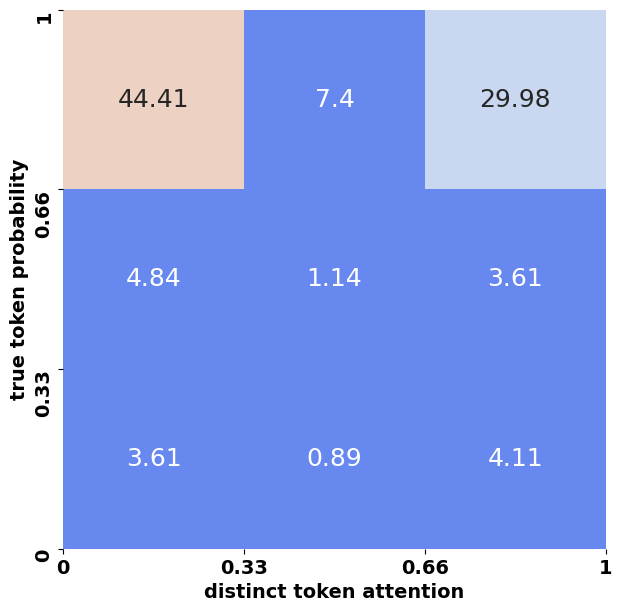

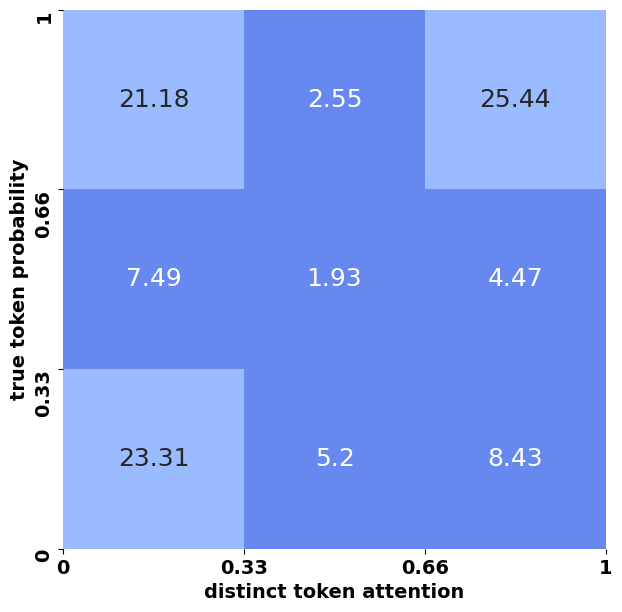

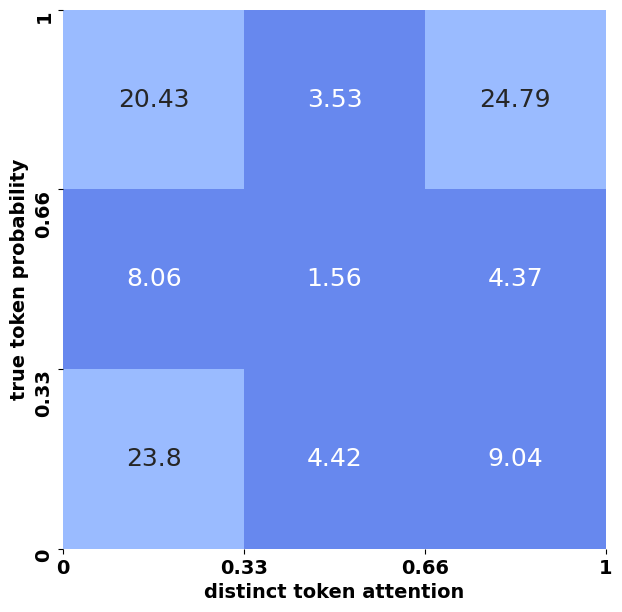

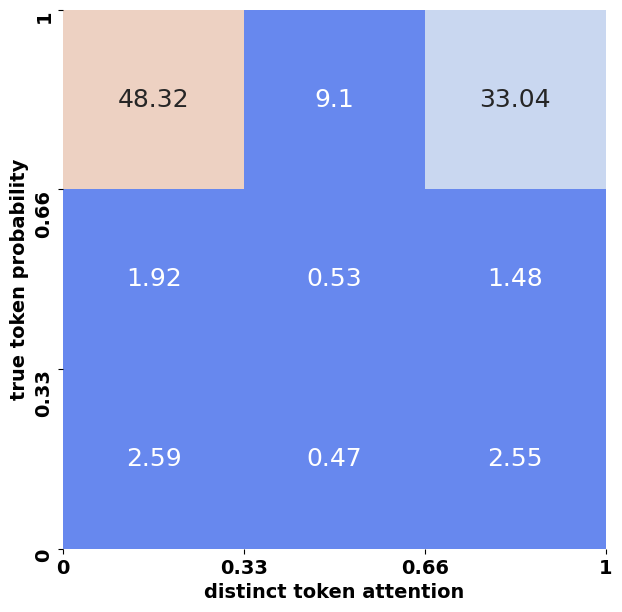

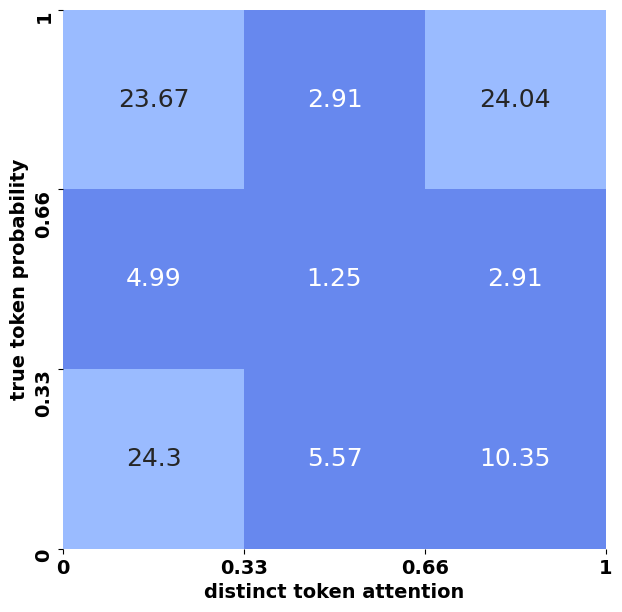

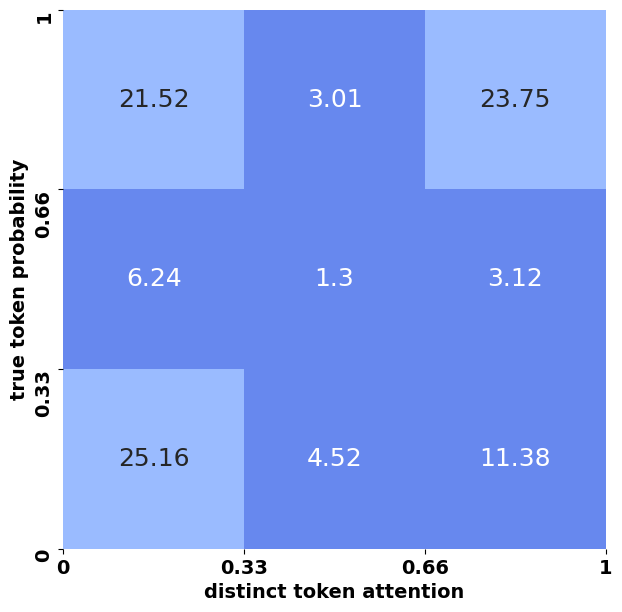

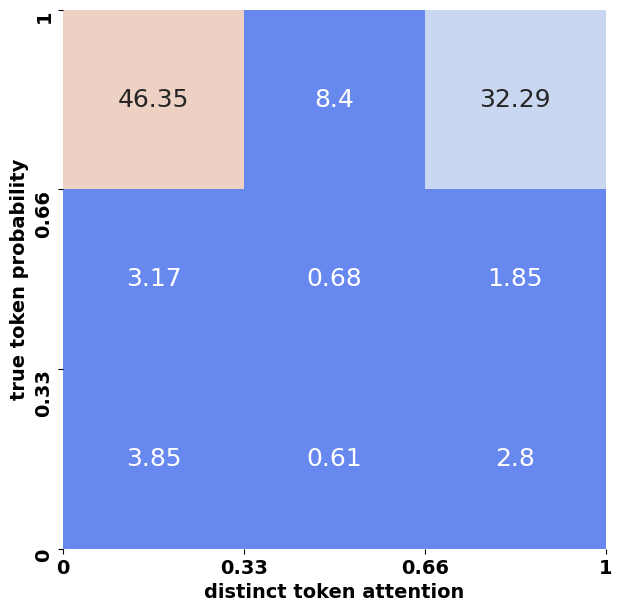

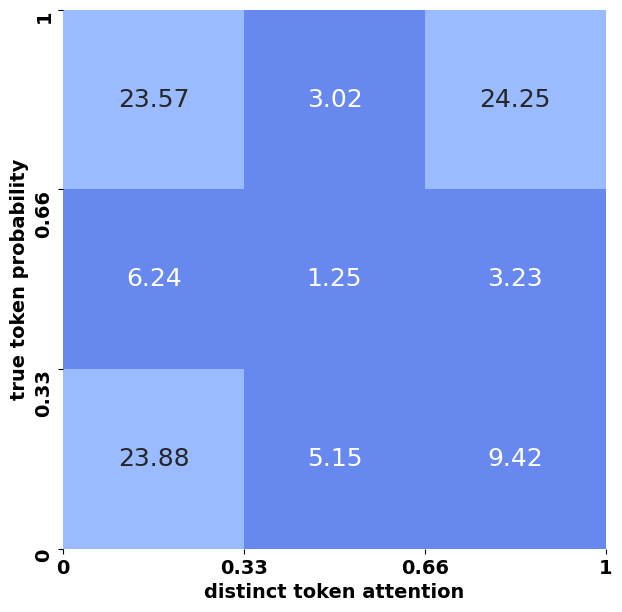

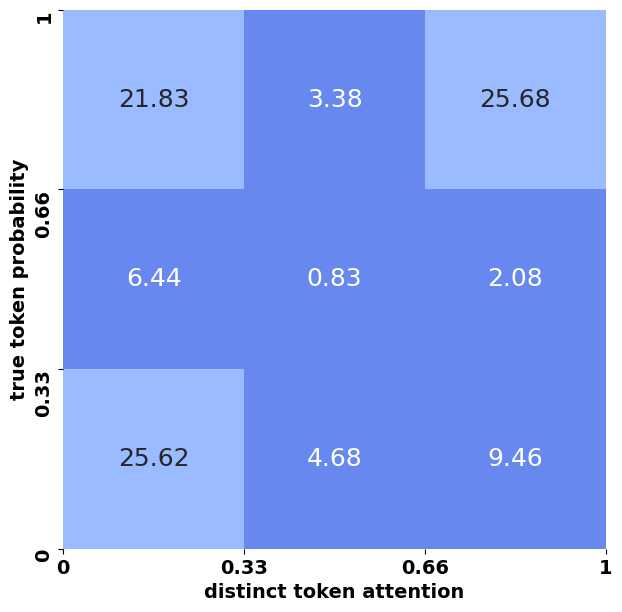

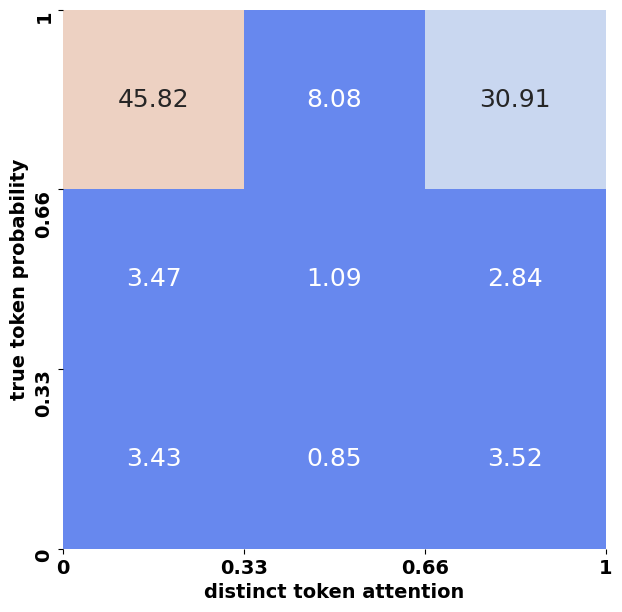

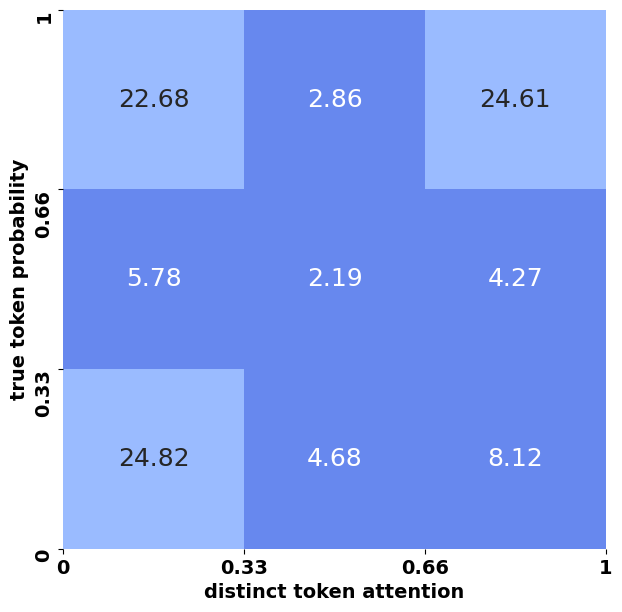

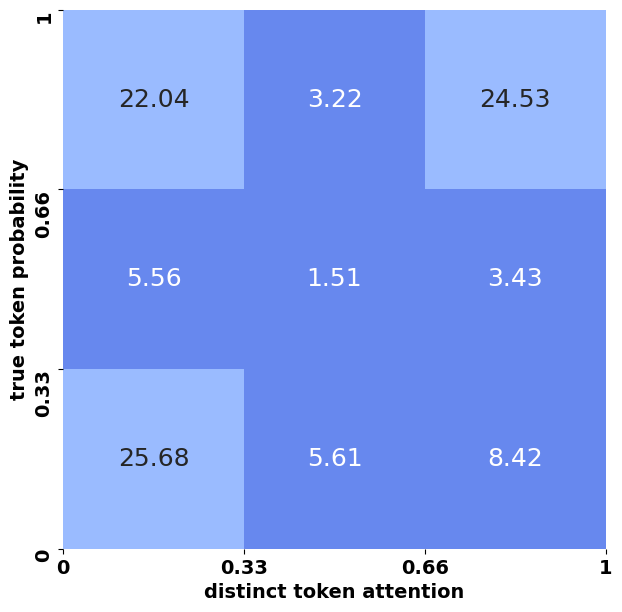

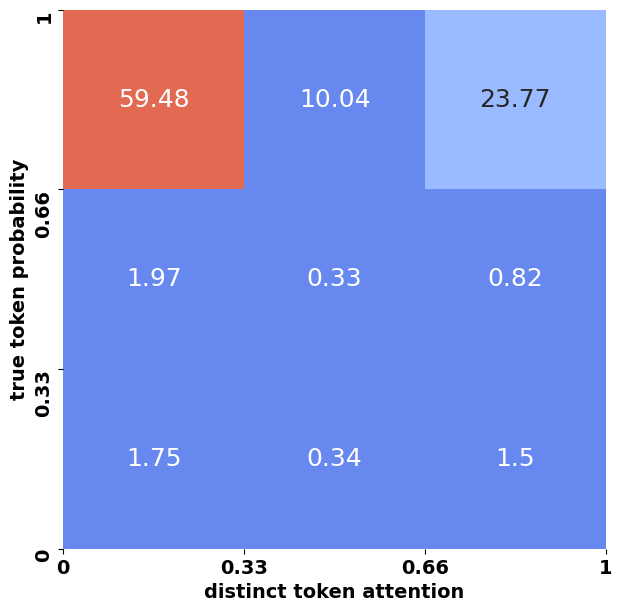

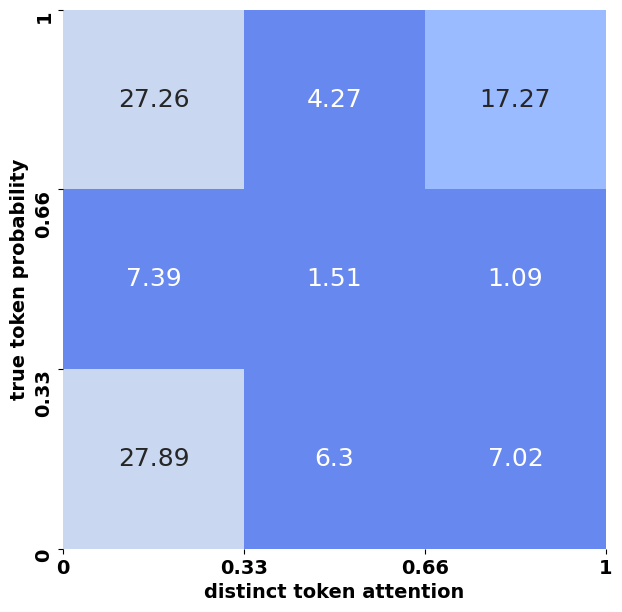

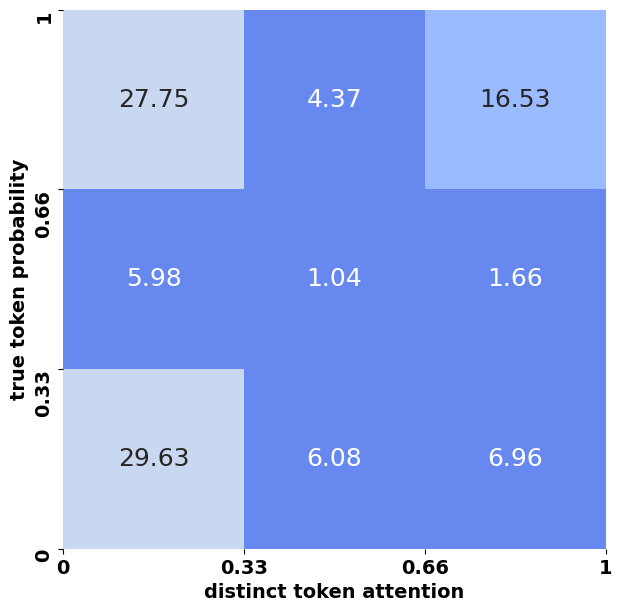

In [46]:
from transformers import get_cosine_schedule_with_warmup
import random

from tqdm import tqdm as tqdm
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


train_seeds = [1234, 1235, 1236, 1237, 1238]

for n_seed in train_seeds:

    print("\n Training Seed:", n_seed)
    set_seed(n_seed)

    batch_size = 32
    num_epochs = 30
    lr = 5e-5
    weight_decay = 1e-3
    momentum = 0.99
    
    
    torch.manual_seed(n_seed)
    # Build model
    model_cfg = Config(debug=False, d_model=64, n_heads=4, d_head=64,
                       d_mlp=256, n_layers=1, n_ctx=256,
                       d_vocab=tokenizer.vocab_size)
    model = DemoTransformer(model_cfg).cuda()

    # -------------------------------
    # Optimizer: SGD + momentum
    # -------------------------------
    
    
    optimizer = torch.optim.AdamW([{'params':model.embed.parameters(),"lr":30*lr,"weight_decay":weight_decay},
                       {"params":model.pos_embed.parameters(),"lr":1*lr,"weight_decay":weight_decay},
                       {'params':model.blocks[0].attn.W_Q,'lr':30*lr,"weight_decay":weight_decay},
                       {'params':model.blocks[0].attn.b_Q,'lr':1*lr,"weight_decay":weight_decay},
                       {'params':model.blocks[0].attn.W_K,'lr':30*lr,"weight_decay":weight_decay},
                       {'params':model.blocks[0].attn.b_K,'lr':1*lr,"weight_decay":weight_decay},
                       {'params':model.blocks[0].attn.W_V,'lr':lr,"weight_decay":weight_decay},
                       {'params':model.blocks[0].attn.b_V,'lr':lr,"weight_decay":weight_decay},
                       {'params':model.blocks[0].attn.W_O,'lr':lr,"weight_decay":weight_decay},
                       {'params':model.blocks[0].attn.b_O,'lr':lr,"weight_decay":weight_decay},
                       {'params':model.cls_head.parameters(),'lr':lr,"weight_decay":weight_decay},
                           ],lr=lr)


#     optimizer = torch.optim.SGD([{'params':model.embed.parameters(),"lr":100*lr,"momentum":0.99,"weight_decay":weight_decay},
#                            {"params":model.pos_embed.parameters(),"lr":100*lr,"momentum":0.99,"weight_decay":weight_decay},
#                            {'params':model.blocks[0].attn.W_Q,'lr':100*lr,"momentum":0.99,"weight_decay":weight_decay},
#                            {'params':model.blocks[0].attn.b_Q,'lr':100*lr,"momentum":0.99,"weight_decay":weight_decay},
#                            {'params':model.blocks[0].attn.W_K,'lr':100*lr,"momentum":0.99,"weight_decay":weight_decay},
#                            {'params':model.blocks[0].attn.b_K,'lr':100*lr,"momentum":0.99,"weight_decay":weight_decay},
#                            {'params':model.blocks[0].attn.W_V,'lr':lr,"momentum":0.99,"weight_decay":weight_decay},
#                            {'params':model.blocks[0].attn.b_V,'lr':lr,"momentum":0.99,"weight_decay":weight_decay},
#                            {'params':model.blocks[0].attn.W_O,'lr':lr,"momentum":0.99,"weight_decay":weight_decay},
#                            {'params':model.blocks[0].attn.b_O,'lr':lr,"momentum":0.99,"weight_decay":weight_decay},
#                            {'params':model.cls_head.parameters(),'lr':lr,"momentum":0.99,"weight_decay":weight_decay},
#                                ],lr=lr)

    # -------------------------------
    # Scheduler setup
    # Total steps = epochs * batches
    # -------------------------------
    total_steps = num_epochs * len(train_dataloader)
    warmup_steps = total_steps // 10    # 10% warmup

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    criterion = nn.CrossEntropyLoss()

    print("Total steps:", total_steps)
    print("Evaluating every 10 epochs")
    
    step_count = 0
    ep_loss = []
    
    for epoch in tqdm(range(num_epochs)):
        model.train()
        losses = []

        for batch in train_dataloader:

            inputs, rationales, mask, tlabels = batch
            inputs = inputs.cuda()
            tlabels = tlabels.cuda()
            mask = mask.cuda()

            logits, _ = model(inputs)
            loss = criterion(logits, tlabels)

            loss.backward()

            # Gradient clipping (IMPORTANT for transformers)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            step_count += 1
            losses.append(loss.item())

        ep_loss.append(np.mean(losses))

        # -------------------------------
        # Evaluation every 10 epochs
        # -------------------------------
        if (epoch + 1) % 10 == 0:
            print(f"\nEpoch {epoch+1}/{num_epochs}: Loss = {ep_loss[-1]:.4f}")
            calculate_performance(model, train_dataloader, dataset="train_set")
            calculate_performance(model, validation_dataloader, dataset="validation_set")
            calculate_performance(model, test_dataloader, dataset="test_set")

    # Final eval
    print("\nFinal Evaluation for Seed:", n_seed)
    calculate_performance(model, train_dataloader, dataset="train_set")
    calculate_performance(model, validation_dataloader, dataset="validation_set")
    calculate_performance(model, test_dataloader, dataset="test_set")
    
    # Save the model's state_dict
    torch.save(model.state_dict(), "./Saved_Models/1_layer_Faster_QK_HX_"+str(n_seed)+".pt")
    

    # Heatmaps AFTER training (not inside loop)
    plot_heatmaps(model, train_dataloader, name=f"1_layer_Faster_train_no_res_{n_seed}")
    plot_heatmaps(model, validation_dataloader, name=f"1_layer_Faster_val_no_res_{n_seed}")
    plot_heatmaps(model, test_dataloader, name=f"1_layer_Faster_test_no_res_{n_seed}")
    
    #metric,_ = evaluate_interpretability_dataset(model,tokenizer,train_dataloader,device)

In [49]:
# Main evaluation script
seeds_list = [1234, 1235, 1236, 1237, 1238]

# Load your dataset and model setup here
# val_dataloader = ...

for nseed in seeds_list:
    BASELINE_CKPT = f"./Saved_Models/Faster_QK_HX_{nseed}.pt"
    
    print(f"Initializing baseline model instance...{nseed}")
    
    baseline_cfg = Config(debug=False, d_model=64, n_heads=4, d_head=64,
                       d_mlp=256, n_layers=1, n_ctx=256,
                       d_vocab=tokenizer.vocab_size)
    baseline = DemoTransformer(baseline_cfg).cuda()

    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt)
    baseline.eval()
    print("Faster QK model loaded.")
    
    # Evaluation
    n_samples = 15000
    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []
    
    sample_count = 0
    
    with torch.no_grad():
        for batch in tqdm(train_dataloader):
            if sample_count >= n_samples:
                break
            
            inputs, rationales, mask, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            batch_size = inputs.size(0)
            
            # Process each sample in the batch
            for i in range(batch_size):
                if sample_count >= n_samples:
                    break
                
                # Get single sample
                sample_input = inputs[i:i+1]  # Keep batch dimension
                sample_rationale = rationales[i]
                sample_label = labels[i]
                
                # Get predictions with attention for this sample
                logits, attention_weights = baseline(sample_input)
                
                # Convert attention to numpy (extract from batch dimension)
                attention_weights_np = [att[0].cpu().numpy() for att in attention_weights]
                
                # Get predicted class and probability
                probs = F.softmax(logits, dim=-1)
                predicted_class = logits.argmax(-1).item()
                original_prob = probs[0, predicted_class].item()
                
                # Get rationale positions (indices where rationales == 1)
                #rationale_positions = (sample_rationale == 1).nonzero(as_tuple=True)[0].cpu().tolist()
                #if not rationale_positions:
                #    continue
                
                # Compute attention mass metrics
                rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs = \
                    attention_mass_classification(attention_weights_np, sample_rationale, alpha=1)
                
                # Compute comprehensiveness and sufficiency
                comp, suff = compute_comprehensiveness_sufficiency_classification(
                    baseline, sample_input, predicted_class, original_prob,
                    rollout_attn_probs, sample_rationale , k_percent=5, device=device
                )
                
                Attn_Scores_Rollout.append(rollout_mass)
                Attn_Scores_LayerAvg.append(layer_avg_mass)
                Attn_Scores_MaxPool.append(max_pool_mass)
                Comprehensiveness_Scores.append(comp)
                Sufficiency_Scores.append(suff)
                
                sample_count += 1
    
    # Print results
    print(f"Faster Train Results...{nseed}")
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")

Initializing baseline model instance...1234
Faster QK model loaded.


 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍   | 469/481 [02:05<00:03,  3.74it/s]


Faster Train Results...1234
Rollout:           0.3158
Layer-Avg:         0.3158
Max-Pooling:       0.3158
Comprehensiveness: 0.4610 (higher = better)
Sufficiency:       0.2595 (lower = better)
Initializing baseline model instance...1235
Faster QK model loaded.


 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍   | 469/481 [02:06<00:03,  3.71it/s]


Faster Train Results...1235
Rollout:           0.3053
Layer-Avg:         0.3053
Max-Pooling:       0.3053
Comprehensiveness: 0.5001 (higher = better)
Sufficiency:       0.3885 (lower = better)
Initializing baseline model instance...1236
Faster QK model loaded.


...

Faster Train Results...1236
Rollout:           0.3121
Layer-Avg:         0.3121
Max-Pooling:       0.3121
Comprehensiveness: 0.4994 (higher = better)
Sufficiency:       0.3703 (lower = better)
Initializing baseline model instance...1237
Faster QK model loaded.


 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍   | 469/481 [02:27<00:03,  3.19it/s]


Faster Train Results...1237
Rollout:           0.3119
Layer-Avg:         0.3119
Max-Pooling:       0.3119
Comprehensiveness: 0.4756 (higher = better)
Sufficiency:       0.3099 (lower = better)
Initializing baseline model instance...1238
Faster QK model loaded.


 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍   | 469/481 [02:19<00:03,  3.35it/s]

Faster Train Results...1238
Rollout:           0.2967
Layer-Avg:         0.2967
Max-Pooling:       0.2967
Comprehensiveness: 0.5082 (higher = better)
Sufficiency:       0.3889 (lower = better)


In [53]:
# Main evaluation script
seeds_list = [1234, 1235, 1236, 1237, 1238]

# Load your dataset and model setup here
# val_dataloader = ...

for nseed in seeds_list:
    BASELINE_CKPT = f"./Saved_Models/Faster_QK_HX_{nseed}.pt"
    
    print(f"Initializing baseline model instance...{nseed}")
    
    baseline_cfg = Config(debug=False, d_model=64, n_heads=4, d_head=64,
                       d_mlp=256, n_layers=1, n_ctx=256,
                       d_vocab=tokenizer.vocab_size)
    baseline = DemoTransformer(baseline_cfg).cuda()

    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt)
    baseline.eval()
    print("Faster QK model loaded.")
    
    # Evaluation
    n_samples = 5000
    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []
    
    sample_count = 0
    
    with torch.no_grad():
        for batch in tqdm(validation_dataloader):
            if sample_count >= n_samples:
                break
            
            inputs, rationales, mask, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            batch_size = inputs.size(0)
            
            # Process each sample in the batch
            for i in range(batch_size):
                if sample_count >= n_samples:
                    break
                
                # Get single sample
                sample_input = inputs[i:i+1]  # Keep batch dimension
                sample_rationale = rationales[i]
                sample_label = labels[i]
                
                # Get predictions with attention for this sample
                logits, attention_weights = baseline(sample_input)
                
                # Convert attention to numpy (extract from batch dimension)
                attention_weights_np = [att[0].cpu().numpy() for att in attention_weights]
                
                # Get predicted class and probability
                probs = F.softmax(logits, dim=-1)
                predicted_class = logits.argmax(-1).item()
                original_prob = probs[0, predicted_class].item()
                
                # Get rationale positions (indices where rationales == 1)
                #rationale_positions = (sample_rationale == 1).nonzero(as_tuple=True)[0].cpu().tolist()
                #if not rationale_positions:
                #    continue
                
                # Compute attention mass metrics
                rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs = \
                    attention_mass_classification(attention_weights_np, sample_rationale, alpha=1)
                
                # Compute comprehensiveness and sufficiency
                comp, suff = compute_comprehensiveness_sufficiency_classification(
                    baseline, sample_input, predicted_class, original_prob,
                    rollout_attn_probs, sample_rationale , k_percent=5, device=device
                )
                
                Attn_Scores_Rollout.append(rollout_mass)
                Attn_Scores_LayerAvg.append(layer_avg_mass)
                Attn_Scores_MaxPool.append(max_pool_mass)
                Comprehensiveness_Scores.append(comp)
                Sufficiency_Scores.append(suff)
                
                sample_count += 1
    
    # Print results
    print(f"Faster Train Results...{nseed}")
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")

Initializing baseline model instance...1234
Faster QK model loaded.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:49<00:00,  1.24it/s]


Faster Train Results...1234
Rollout:           0.3137
Layer-Avg:         0.3137
Max-Pooling:       0.3137
Comprehensiveness: 0.4637 (higher = better)
Sufficiency:       0.2622 (lower = better)
Initializing baseline model instance...1235
Faster QK model loaded.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:48<00:00,  1.25it/s]


Faster Train Results...1235
Rollout:           0.3009
Layer-Avg:         0.3009
Max-Pooling:       0.3009
Comprehensiveness: 0.4992 (higher = better)
Sufficiency:       0.3557 (lower = better)
Initializing baseline model instance...1236
Faster QK model loaded.


...

Faster Train Results...1236
Rollout:           0.3012
Layer-Avg:         0.3012
Max-Pooling:       0.3012
Comprehensiveness: 0.4769 (higher = better)
Sufficiency:       0.3520 (lower = better)
Initializing baseline model instance...1237
Faster QK model loaded.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:49<00:00,  1.24it/s]


Faster Train Results...1237
Rollout:           0.3083
Layer-Avg:         0.3083
Max-Pooling:       0.3083
Comprehensiveness: 0.4503 (higher = better)
Sufficiency:       0.3064 (lower = better)
Initializing baseline model instance...1238
Faster QK model loaded.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:49<00:00,  1.23it/s]

Faster Train Results...1238
Rollout:           0.2919
Layer-Avg:         0.2919
Max-Pooling:       0.2919
Comprehensiveness: 0.4940 (higher = better)
Sufficiency:       0.3577 (lower = better)


In [55]:
# Main evaluation script
seeds_list = [1234, 1235, 1236, 1237, 1238]

# Load your dataset and model setup here
# val_dataloader = ...

for nseed in seeds_list:
    BASELINE_CKPT = f"./Saved_Models/Faster_QK_HX_{nseed}.pt"
    
    print(f"Initializing baseline model instance...{nseed}")
    
    baseline_cfg = Config(debug=False, d_model=64, n_heads=4, d_head=64,
                       d_mlp=256, n_layers=1, n_ctx=256,
                       d_vocab=tokenizer.vocab_size)
    baseline = DemoTransformer(baseline_cfg).cuda()

    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt)
    baseline.eval()
    print("Faster QK model loaded.")
    
    # Evaluation
    n_samples = 5000
    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []
    
    sample_count = 0
    
    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            if sample_count >= n_samples:
                break
            
            inputs, rationales, mask, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            batch_size = inputs.size(0)
            
            # Process each sample in the batch
            for i in range(batch_size):
                if sample_count >= n_samples:
                    break
                
                # Get single sample
                sample_input = inputs[i:i+1]  # Keep batch dimension
                sample_rationale = rationales[i]
                sample_label = labels[i]
                
                # Get predictions with attention for this sample
                logits, attention_weights = baseline(sample_input)
                
                # Convert attention to numpy (extract from batch dimension)
                attention_weights_np = [att[0].cpu().numpy() for att in attention_weights]
                
                # Get predicted class and probability
                probs = F.softmax(logits, dim=-1)
                predicted_class = logits.argmax(-1).item()
                original_prob = probs[0, predicted_class].item()
                
                # Get rationale positions (indices where rationales == 1)
                #rationale_positions = (sample_rationale == 1).nonzero(as_tuple=True)[0].cpu().tolist()
                #if not rationale_positions:
                #    continue
                
                # Compute attention mass metrics
                rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs = \
                    attention_mass_classification(attention_weights_np, sample_rationale, alpha=1)
                
                # Compute comprehensiveness and sufficiency
                comp, suff = compute_comprehensiveness_sufficiency_classification(
                    baseline, sample_input, predicted_class, original_prob,
                    rollout_attn_probs, sample_rationale , k_percent=5, device=device
                )
                
                Attn_Scores_Rollout.append(rollout_mass)
                Attn_Scores_LayerAvg.append(layer_avg_mass)
                Attn_Scores_MaxPool.append(max_pool_mass)
                Comprehensiveness_Scores.append(comp)
                Sufficiency_Scores.append(suff)
                
                sample_count += 1
    
    # Print results
    print(f"Faster Train Results...{nseed}")
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")

Initializing baseline model instance...1234
Faster QK model loaded.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:50<00:00,  1.21it/s]


Faster Train Results...1234
Rollout:           0.3223
Layer-Avg:         0.3223
Max-Pooling:       0.3223
Comprehensiveness: 0.4610 (higher = better)
Sufficiency:       0.2637 (lower = better)
Initializing baseline model instance...1235
Faster QK model loaded.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:50<00:00,  1.21it/s]


Faster Train Results...1235
Rollout:           0.3091
Layer-Avg:         0.3091
Max-Pooling:       0.3091
Comprehensiveness: 0.5015 (higher = better)
Sufficiency:       0.3482 (lower = better)
Initializing baseline model instance...1236
Faster QK model loaded.


...

Faster Train Results...1236
Rollout:           0.3146
Layer-Avg:         0.3146
Max-Pooling:       0.3146
Comprehensiveness: 0.4758 (higher = better)
Sufficiency:       0.3604 (lower = better)
Initializing baseline model instance...1237
Faster QK model loaded.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:36<00:00,  1.69it/s]


Faster Train Results...1237
Rollout:           0.3123
Layer-Avg:         0.3123
Max-Pooling:       0.3123
Comprehensiveness: 0.4625 (higher = better)
Sufficiency:       0.3139 (lower = better)
Initializing baseline model instance...1238
Faster QK model loaded.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:16<00:00,  3.73it/s]

Faster Train Results...1238
Rollout:           0.2962
Layer-Avg:         0.2962
Max-Pooling:       0.2962
Comprehensiveness: 0.4953 (higher = better)
Sufficiency:       0.3488 (lower = better)


In [ ]:
#px.line(y=losses, x=np.arange(len(losses))*(model_cfg.n_ctx * batch_size), labels={"y":"Loss", "x":"Tokens"}, title="Training curve for my tiny demo model!")


In [ ]:
# setting1 = "same_lr_train_no_res_connection"
# setting2 = "same_lr_validation_no_res_connection"
# setting3 = "same_lr_test_no_res_connection"


In [ ]:
    # model.eval()
    # pred = []
    # gt = []
    # for c, batch in tqdm.tqdm(enumerate(dataloader)):
    #     inputs,rationales,mask,tlabels = batch
    #     inputs,tlabels,mask = inputs.to(device),tlabels.to(device),mask.to(device)
    #     _,outputs,_= model(inputs)
    #     #print(outputs.shape)
    #     pred.append(torch.argmax(outputs,dim=1).cpu())
    #     gt.append(tlabels.cpu())
    #     #print(len(pred))
    # pred = torch.hstack(pred)
    # #print(pred.size())
    # gt = torch.hstack(gt)
    # print("Acccuracy on "+ dataset + ":", sum(pred == gt)/len(pred))
    # model.train()